# RT_check_NTHU: 2D 超導薄膜 R-T 定量分析

本 notebook 針對零磁場 (`B=0`) 的三欄資料（Temperature, Resistance, Current）做完整分析：

1. 資料載入與原始 R-T 視覺化
2. 基本臨界溫度萃取：$T_{c,\mathrm{onset}}$, $T_{c,\mathrm{mid}}$, $T_{c,\mathrm{zero}}$
3. 2D Aslamazov-Larkin (AL) 漲落導電分析
4. BKT (Halperin-Nelson) 轉變擬合

請先確認 `RT_data.csv` 位在 notebook 執行目錄，或修改 `csv_path`。

## 1) Data Loading & Visualization

先讀取溫度與電阻資料並排序（以溫度遞增），畫出原始 R-T 曲線。

物理上，超導轉變會在某個溫度區間發生明顯電阻下降，後續分析會以這段區間來定義各種 $T_c$。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

plt.rcParams['figure.figsize'] = (7.5, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    for cand in [start, *start.parents]:
        if (cand / 'Processed_data').exists():
            return cand
    raise FileNotFoundError('找不到包含 Processed_data/ 的專案根目錄。')


def load_rt_file(path: Path) -> pd.DataFrame:
    raw = pd.read_excel(path)

    candidates = [
        ('T_K', 'R_Ohm'),
        ('Temperature', 'Resistance'),
        ('T', 'R'),
    ]

    t_col = None
    r_col = None
    for t_try, r_try in candidates:
        if t_try in raw.columns and r_try in raw.columns:
            t_col, r_col = t_try, r_try
            break

    if t_col is None or r_col is None:
        numeric_cols = []
        for c in raw.columns:
            s = pd.to_numeric(raw[c], errors='coerce')
            if s.notna().sum() > 0:
                numeric_cols.append(c)
        if len(numeric_cols) < 2:
            raise ValueError(f'{path.name} 無法辨識 T/R 欄位，欄名={list(raw.columns)}')
        t_col, r_col = numeric_cols[0], numeric_cols[1]

    df = raw[[t_col, r_col]].copy()
    df.columns = ['Temperature', 'Resistance']
    df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
    df['Resistance'] = pd.to_numeric(df['Resistance'], errors='coerce')
    df = df.dropna(subset=['Temperature', 'Resistance'])
    df = df.sort_values('Temperature').reset_index(drop=True)

    # 去重溫度點，避免數值微分時遇到重複 x
    df = df.groupby('Temperature', as_index=False)['Resistance'].median()
    return df


PROJECT_ROOT = find_project_root()
RT_DIR = PROJECT_ROOT / 'Processed_data' / 'analysis_inputs' / 'Pure_RT'

all_rt_paths = sorted(RT_DIR.glob('RT_*_NTHU.xlsx'))
rt_paths = [p for p in all_rt_paths if '2probe' not in p.stem.lower()]

if not rt_paths:
    raise FileNotFoundError(
        f'在 {RT_DIR} 找不到可用的 NTHU RT 檔案。\n'
        '預期檔名像 RT_I_1_uA_NTHU.xlsx，且不包含 2probe。'
    )

rt_datasets = []
for path in rt_paths:
    df = load_rt_file(path)
    dataset_name = path.stem.replace('_NTHU', '')
    rt_datasets.append({'name': dataset_name, 'path': path, 'df': df})

info_rows = []
for ds in rt_datasets:
    d = ds['df']
    info_rows.append({
        'dataset': ds['name'],
        'points': len(d),
        'T_min(K)': float(d['Temperature'].min()),
        'T_max(K)': float(d['Temperature'].max()),
        'R_min(Ohm)': float(d['Resistance'].min()),
        'R_max(Ohm)': float(d['Resistance'].max()),
        'source': str(ds['path'].relative_to(PROJECT_ROOT)),
    })

info_df = pd.DataFrame(info_rows).sort_values('dataset').reset_index(drop=True)
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'載入 RT 檔案數量（已排除 2probe）: {len(rt_datasets)}')
display(info_df)


PROJECT_ROOT: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device
載入 RT 檔案數量（已排除 2probe）: 4


,dataset,points,T_min(K),T_max(K),R_min(Ohm),R_max(Ohm),source
0,RT_I_10_uA,5471,85.409,100.28,-0.000240,0.95204,Processed_data/analysis_inputs/Pure_RT/RT_I_10...
1,RT_I_1_uA,30547,83.983,298.46,-0.002000,2.74340,Processed_data/analysis_inputs/Pure_RT/RT_I_1_...
2,RT_I_3.16_uA,5859,83.880,100.22,-0.000405,0.93232,Processed_data/analysis_inputs/Pure_RT/RT_I_3....
3,RT_I_316_nA,11037,82.074,100.25,0.000770,0.95716,Processed_data/analysis_inputs/Pure_RT/RT_I_31...


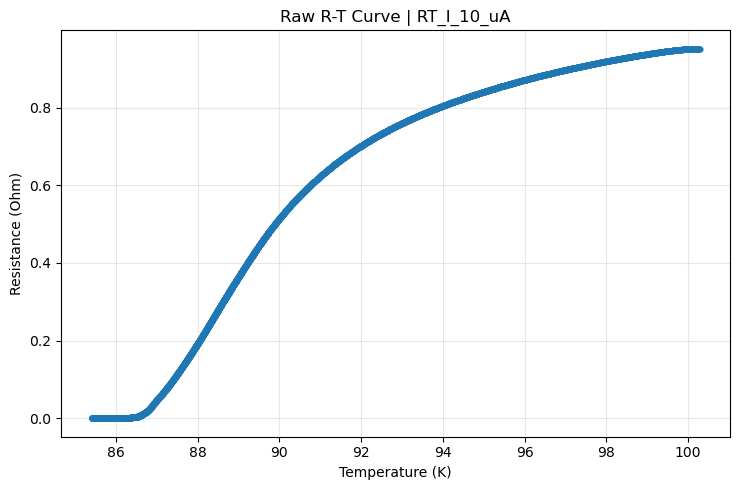

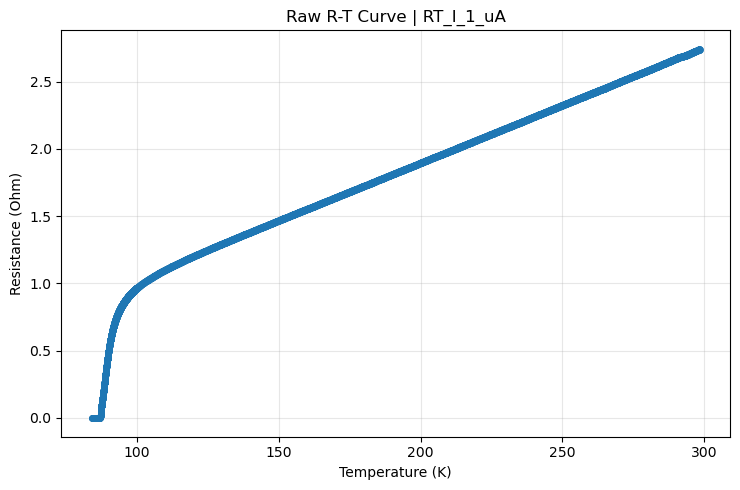

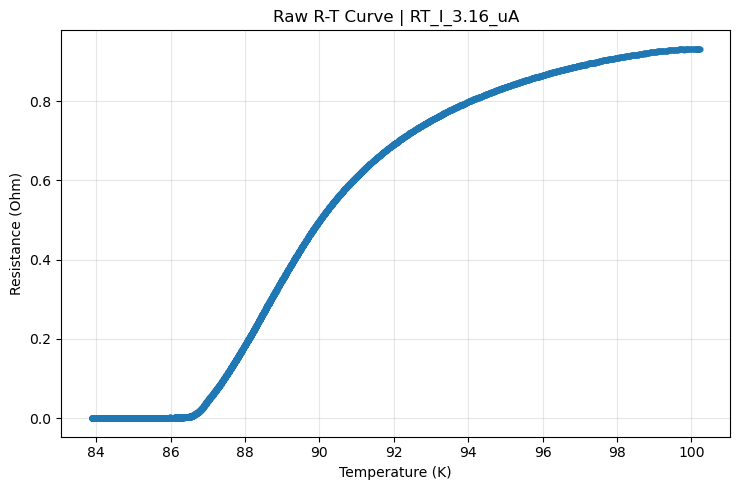

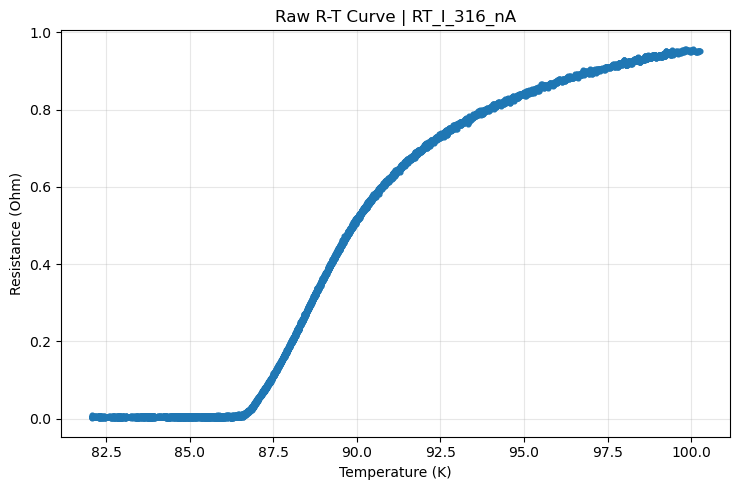

In [3]:
# 每一條 RT 曲線分開畫（不疊在同一張）
for ds in rt_datasets:
    name = ds['name']
    df = ds['df']
    T = df['Temperature'].to_numpy(dtype=float)
    R = df['Resistance'].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.plot(T, R, 'o-', lw=1.6, ms=3.4, color='tab:blue')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Resistance (Ohm)')
    ax.set_title(f'Raw R-T Curve | {name}')
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 2) Basic $T_c$ Extraction ($T_{c,\mathrm{onset}}$, $T_{c,\mathrm{mid}}$, $T_{c,\mathrm{zero}}$)

定義方式：

- $T_{c,\mathrm{onset}}$：以 $dR/dT$ 最陡降點（最負斜率）對應溫度表示。
- $T_{c,\mathrm{mid}}$：電阻降到正常態參考值 $R_n$ 的 50% 時對應溫度。
- $T_{c,\mathrm{zero}}$：電阻低於雜訊門檻時的最高溫（視為趨近零電阻）。

其中 $R_n$ 取自 onset 上方小區間的中位數，雜訊門檻取低溫區波動估計與 1% $R_n$ 的較大者。

In [4]:
def bkt_fit_by_grid_search(T_tail: np.ndarray, R_tail: np.ndarray, tbkt_lower: float, tbkt_upper: float):
    """不用 scipy 的 BKT 擬合：對 T_BKT 做 grid search，內層做線性化最小平方法。"""
    if not (np.isfinite(tbkt_lower) and np.isfinite(tbkt_upper)):
        return np.nan, np.nan, np.nan
    if tbkt_upper <= tbkt_lower:
        return np.nan, np.nan, np.nan

    grid = np.linspace(tbkt_lower, tbkt_upper, 300)
    best = None

    for tbkt in grid:
        reduced = T_tail / max(tbkt, 1e-12) - 1.0
        if np.any(reduced <= 0):
            continue

        x = 1.0 / np.sqrt(reduced)
        y = np.log(np.clip(R_tail, 1e-18, None))

        m, c = np.polyfit(x, y, deg=1)  # y = m*x + c
        b = -m
        if b <= 0:
            continue

        R0 = float(np.exp(c))
        pred = R0 * np.exp(-b * x)
        sse = float(np.sum((R_tail - pred) ** 2))

        if best is None or sse < best[0]:
            best = (sse, R0, b, float(tbkt))

    if best is None:
        return np.nan, np.nan, np.nan
    return best[1], best[2], best[3]


def analyze_single_rt(df: pd.DataFrame, dataset_name: str) -> dict:
    T = df['Temperature'].to_numpy(dtype=float)
    R = df['Resistance'].to_numpy(dtype=float)

    if len(T) < 10:
        raise RuntimeError(f'{dataset_name}: 資料點不足，無法穩定分析。')

    # --- 基本 Tc 指標 ---
    dR_dT = np.gradient(R, T)
    idx_onset = int(np.argmin(dR_dT))
    Tc_onset = float(T[idx_onset])

    temp_span = float(T.max() - T.min())
    onset_window_k = max(2.0, 0.08 * temp_span)

    mask_above_onset = (T >= Tc_onset + 0.2 * onset_window_k) & (T <= Tc_onset + onset_window_k)
    if mask_above_onset.sum() < 3:
        mask_above_onset = T > Tc_onset

    R_normal_ref = float(np.median(R[mask_above_onset]))
    R_mid_target = 0.5 * R_normal_ref

    idx_mid = int(np.argmin(np.abs(R - R_mid_target)))
    Tc_mid = float(T[idx_mid])

    low_temp_mask = T <= np.quantile(T, 0.2)
    low_temp_R = R[low_temp_mask]
    if len(low_temp_R) < 3:
        low_temp_R = R[:max(3, len(R) // 10)]

    noise_sigma = float(np.std(low_temp_R - np.median(low_temp_R)))
    noise_threshold = max(3.0 * noise_sigma, 0.01 * abs(R_normal_ref))

    below_noise_idx = np.where(R <= noise_threshold)[0]
    Tc_zero = float(np.max(T[below_noise_idx])) if len(below_noise_idx) > 0 else np.nan

    # --- AL analysis ---
    normal_fit_mask = T >= (Tc_onset + onset_window_k)
    if normal_fit_mask.sum() < 5:
        normal_fit_mask = T >= np.quantile(T, 0.7)

    coef_a, coef_b = np.polyfit(T[normal_fit_mask], R[normal_fit_mask], deg=1)
    Rn = coef_a * T + coef_b

    eps = 1e-12
    valid_sigma_mask = (R > eps) & (Rn > eps)
    delta_sigma = np.full_like(R, np.nan, dtype=float)
    delta_sigma[valid_sigma_mask] = 1.0 / R[valid_sigma_mask] - 1.0 / Rn[valid_sigma_mask]

    fluct_upper = Tc_onset + max(8.0, 0.25 * (T.max() - Tc_onset))
    fluct_mask = (
        (T > Tc_mid)
        & (T <= fluct_upper)
        & np.isfinite(delta_sigma)
        & (delta_sigma > 0)
    )
    if fluct_mask.sum() < 4:
        fluct_mask = (T > Tc_mid) & np.isfinite(delta_sigma) & (delta_sigma > 0)

    T_fluc = T[fluct_mask]
    ds_fluc = delta_sigma[fluct_mask]

    al_slope = np.nan
    al_intercept = np.nan
    x_log = np.array([])
    y_log = np.array([])

    if len(T_fluc) >= 4:
        x_log = np.log(T_fluc - Tc_mid)
        y_log = np.log(ds_fluc)
        al_slope, al_intercept = np.polyfit(x_log, y_log, deg=1)

    # --- BKT analysis ---
    positive_R = R[R > 0]
    R0_fit = np.nan
    b_fit = np.nan
    T_BKT_fit = np.nan
    T_tail = np.array([])
    R_tail = np.array([])

    if len(positive_R) >= 8:
        r_low = max(noise_threshold * 1.2, np.percentile(positive_R, 5))
        r_high = np.percentile(positive_R, 45)

        tail_mask = (R > r_low) & (R < r_high) & (T > (Tc_zero if np.isfinite(Tc_zero) else T.min()))
        if tail_mask.sum() < 6:
            tail_mask = (R > r_low) & (R < np.percentile(positive_R, 60))

        T_tail = T[tail_mask]
        R_tail = R[tail_mask]

        if len(T_tail) >= 6:
            order = np.argsort(T_tail)
            T_tail = T_tail[order]
            R_tail = R_tail[order]

            tbkt_upper = float(np.min(T_tail) - 1e-4)
            tbkt_lower = float(max(T.min(), (Tc_zero - 15.0) if np.isfinite(Tc_zero) else T.min()))
            if tbkt_upper <= tbkt_lower:
                tbkt_lower = float(T.min())
                tbkt_upper = float(np.min(T_tail) - 1e-4)

            R0_fit, b_fit, T_BKT_fit = bkt_fit_by_grid_search(T_tail, R_tail, tbkt_lower, tbkt_upper)

    return {
        'dataset': dataset_name,
        'T': T,
        'R': R,
        'dR_dT': dR_dT,
        'idx_onset': idx_onset,
        'idx_mid': idx_mid,
        'Tc_onset': Tc_onset,
        'Tc_mid': Tc_mid,
        'Tc_zero': Tc_zero,
        'R_normal_ref': R_normal_ref,
        'R_mid_target': R_mid_target,
        'noise_threshold': noise_threshold,
        'onset_window_k': onset_window_k,
        'Rn': Rn,
        'coef_a': coef_a,
        'coef_b': coef_b,
        'x_log': x_log,
        'y_log': y_log,
        'al_slope': float(al_slope) if np.isfinite(al_slope) else np.nan,
        'al_intercept': float(al_intercept) if np.isfinite(al_intercept) else np.nan,
        'T_tail': T_tail,
        'R_tail': R_tail,
        'BKT_R0': float(R0_fit) if np.isfinite(R0_fit) else np.nan,
        'BKT_b': float(b_fit) if np.isfinite(b_fit) else np.nan,
        'BKT_T_BKT': float(T_BKT_fit) if np.isfinite(T_BKT_fit) else np.nan,
    }


analysis_results = []
for ds in rt_datasets:
    res = analyze_single_rt(ds['df'], ds['name'])
    analysis_results.append(res)

    print(f"\n[{res['dataset']}]")
    print(f"Tc_onset = {res['Tc_onset']:.4f} K")
    print(f"Tc_mid   = {res['Tc_mid']:.4f} K")
    print(f"Tc_zero  = {res['Tc_zero']:.4f} K" if np.isfinite(res['Tc_zero']) else 'Tc_zero  = NaN')
    print(f"R_normal_ref = {res['R_normal_ref']:.6g} Ohm")
    print(f"Noise threshold = {res['noise_threshold']:.6g} Ohm")



[RT_I_10_uA]
Tc_onset = 89.7410 K
Tc_mid   = 88.6530 K
Tc_zero  = 86.6450 K
R_normal_ref = 0.61148 Ohm
Noise threshold = 0.00995291 Ohm

[RT_I_1_uA]
Tc_onset = 87.4190 K
Tc_mid   = 89.4730 K
Tc_zero  = 92.0140 K
R_normal_ref = 0.86664 Ohm
Noise threshold = 0.706625 Ohm

[RT_I_3.16_uA]
Tc_onset = 87.1010 K
Tc_mid   = 87.5100 K
Tc_zero  = 86.4240 K
R_normal_ref = 0.21899 Ohm
Noise threshold = 0.0021899 Ohm

[RT_I_316_nA]
Tc_onset = 82.0740 K
Tc_mid   = 82.8710 K
Tc_zero  = 86.3000 K
R_normal_ref = 0.004075 Ohm
Noise threshold = 0.00230078 Ohm


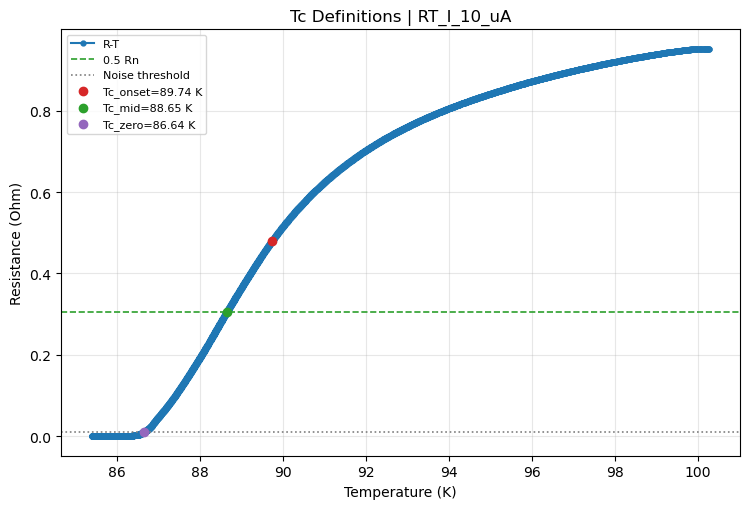

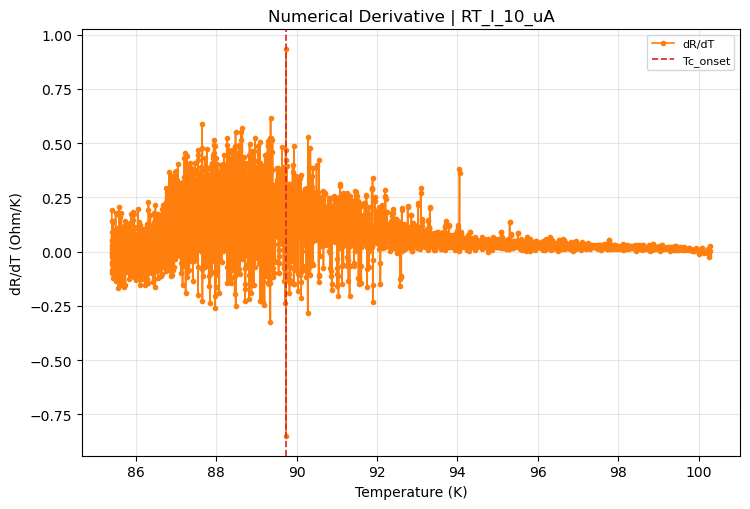

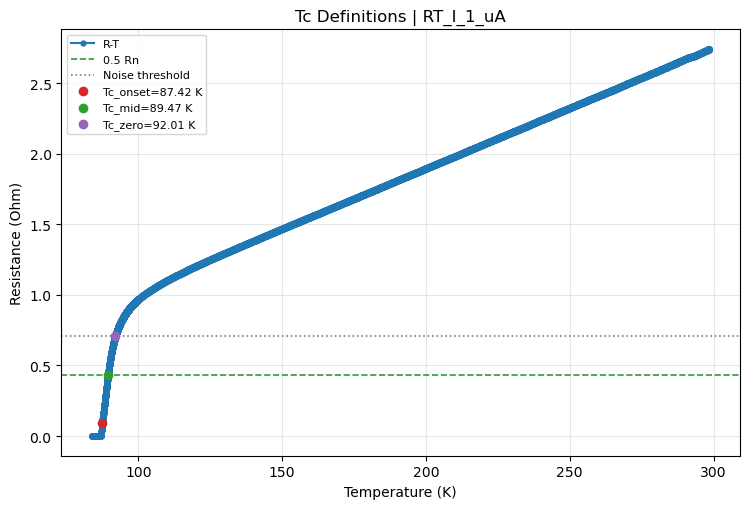

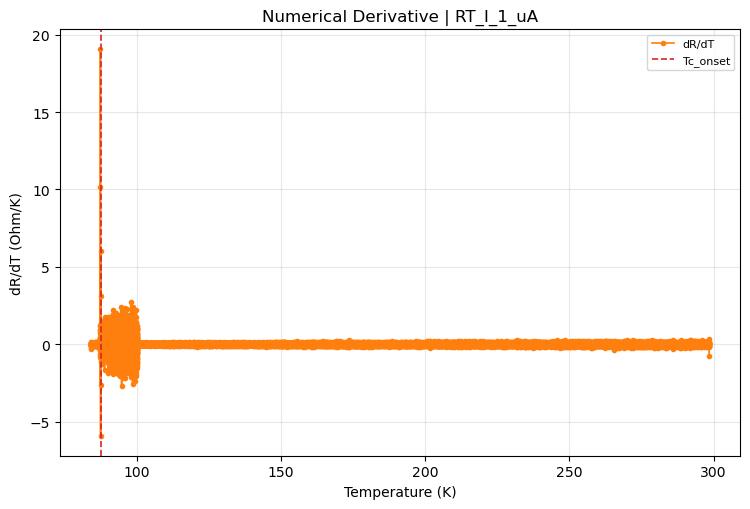

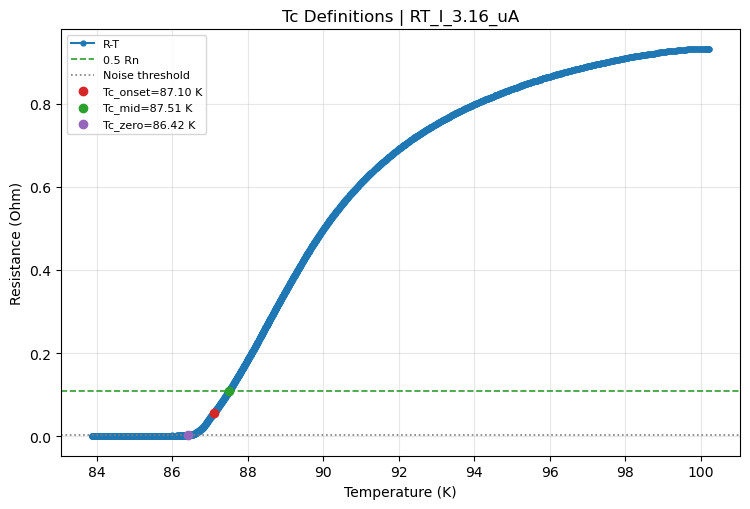

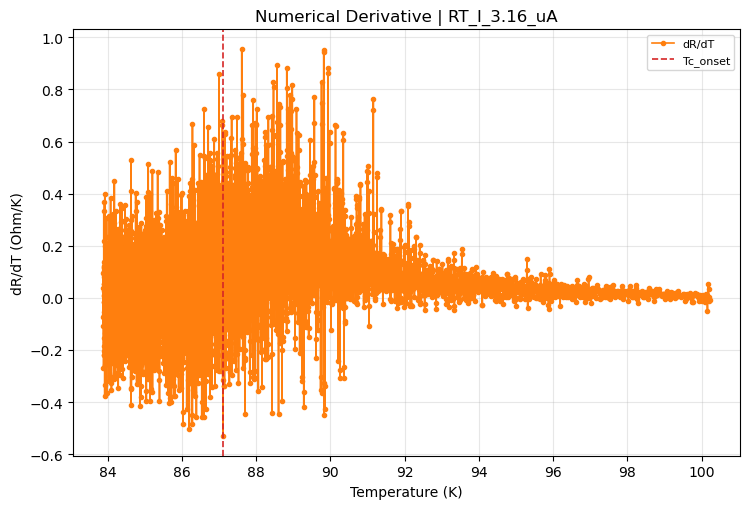

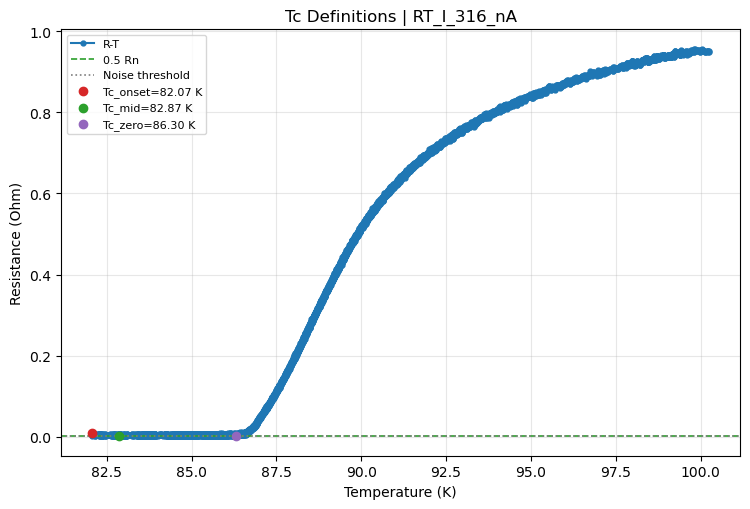

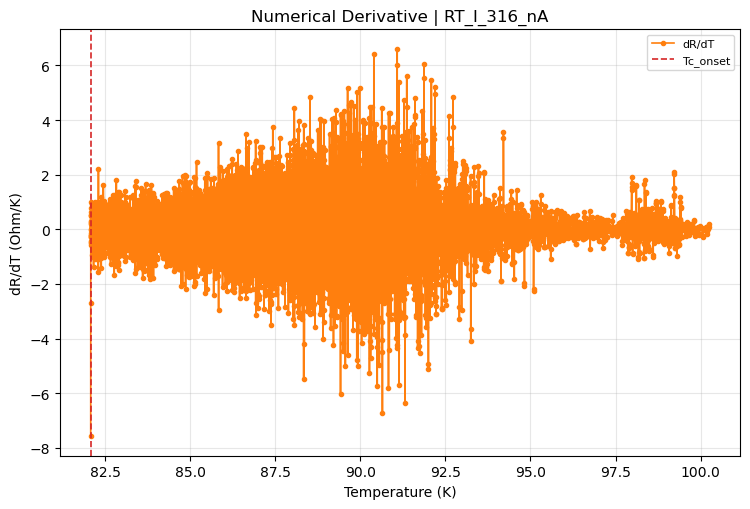

In [5]:
# 每組資料分別顯示 Tc 定義圖與 dR/dT（分開獨立圖）
for res in analysis_results:
    T = res['T']
    R = res['R']
    dR_dT = res['dR_dT']

    # 圖1：Tc 定義
    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    ax.plot(T, R, 'o-', ms=3.5, lw=1.5, color='tab:blue', label='R-T')
    ax.axhline(res['R_mid_target'], color='tab:green', ls='--', lw=1.2, label='0.5 Rn')
    ax.axhline(res['noise_threshold'], color='tab:gray', ls=':', lw=1.2, label='Noise threshold')

    ax.scatter([res['Tc_onset']], [R[res['idx_onset']]], color='tab:red', zorder=5, label=f"Tc_onset={res['Tc_onset']:.2f} K")
    ax.scatter([res['Tc_mid']], [R[res['idx_mid']]], color='tab:green', zorder=5, label=f"Tc_mid={res['Tc_mid']:.2f} K")
    if np.isfinite(res['Tc_zero']):
        i0 = int(np.argmin(np.abs(T - res['Tc_zero'])))
        ax.scatter([res['Tc_zero']], [R[i0]], color='tab:purple', zorder=5, label=f"Tc_zero={res['Tc_zero']:.2f} K")

    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Resistance (Ohm)')
    ax.set_title(f"Tc Definitions | {res['dataset']}")
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # 圖2：dR/dT
    fig, ax2 = plt.subplots(figsize=(7.6, 5.2))
    ax2.plot(T, dR_dT, 'o-', ms=3.0, lw=1.2, color='tab:orange', label='dR/dT')
    ax2.axvline(res['Tc_onset'], color='tab:red', ls='--', lw=1.2, label='Tc_onset')
    ax2.set_xlabel('Temperature (K)')
    ax2.set_ylabel('dR/dT (Ohm/K)')
    ax2.set_title(f'Numerical Derivative | {res["dataset"]}')
    ax2.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 3) 2D Paraconductivity: Aslamazov-Larkin (AL) Analysis

步驟：

1. 在 $T_{c,\mathrm{onset}}$ 上方的線性正常態區，擬合背景電阻 $R_n(T)=aT+b$。
2. 計算 excess conductivity
   $$\Delta\sigma(T)=\frac{1}{R(T)}-\frac{1}{R_n(T)}$$
3. 在轉變上方漲落區作圖：$\ln(\Delta\sigma)$ vs $\ln(T-T_{c,\mathrm{mid}})$，線性擬合斜率。

對理想 2D 超導 AL 行為，斜率預期接近 **-1**。

In [6]:
# AL 數值摘要（每組資料一列）
al_rows = []
for res in analysis_results:
    al_rows.append({
        'dataset': res['dataset'],
        'Rn_slope_a': res['coef_a'],
        'Rn_intercept_b': res['coef_b'],
        'AL_slope': res['al_slope'],
        'AL_intercept': res['al_intercept'],
        'AL_points': len(res['x_log']),
    })

al_df = pd.DataFrame(al_rows).sort_values('dataset').reset_index(drop=True)
display(al_df)


,dataset,Rn_slope_a,Rn_intercept_b,AL_slope,AL_intercept,AL_points
0,RT_I_10_uA,0.032920,-2.302893,-1.093987,-1.231854,1944
1,RT_I_1_uA,0.008617,0.170163,-1.171301,-0.288870,10572
2,RT_I_3.16_uA,0.054620,-4.388143,-1.130029,-0.287612,1398
3,RT_I_316_nA,0.081207,-6.900155,-8.142165,13.813832,3563


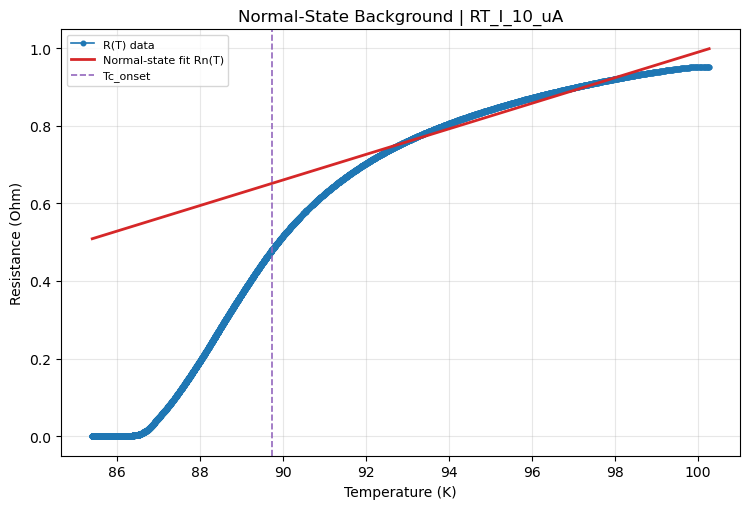

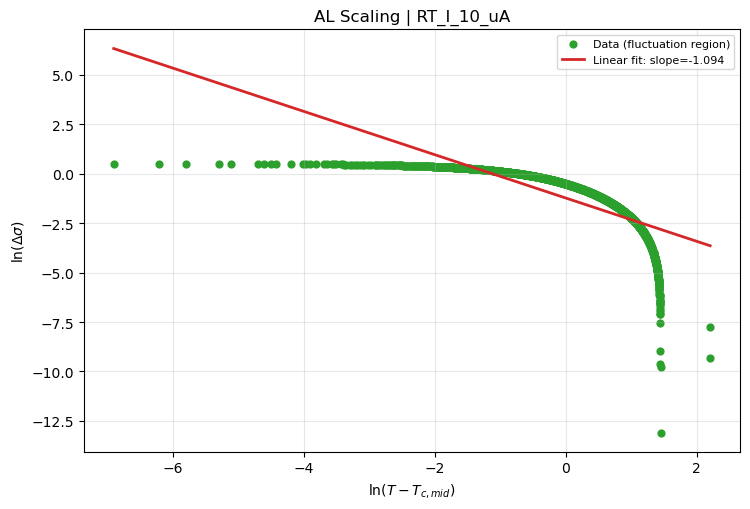

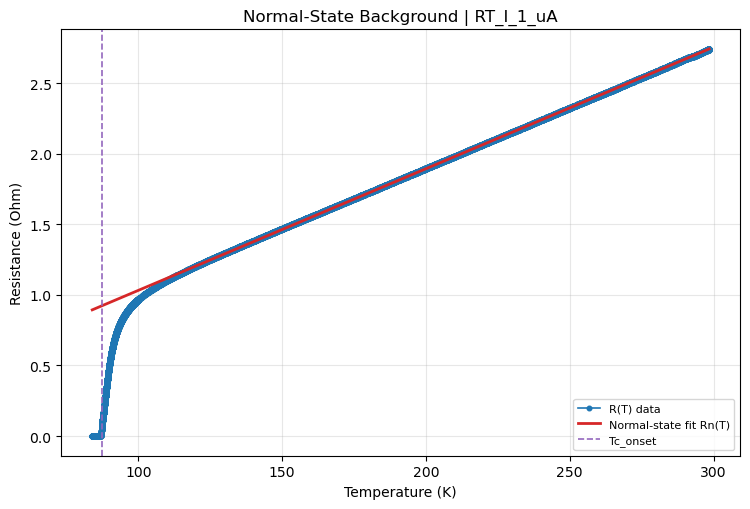

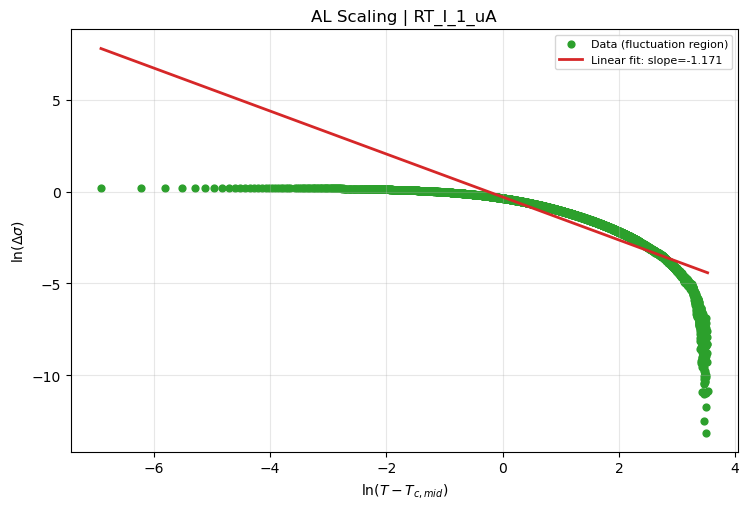

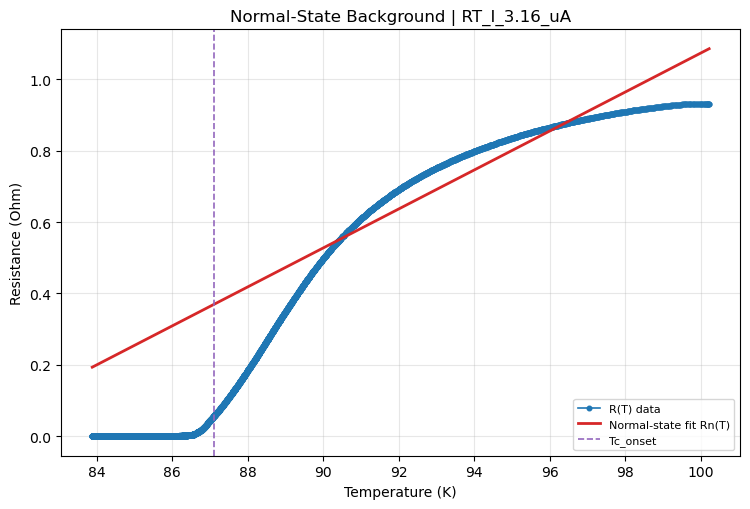

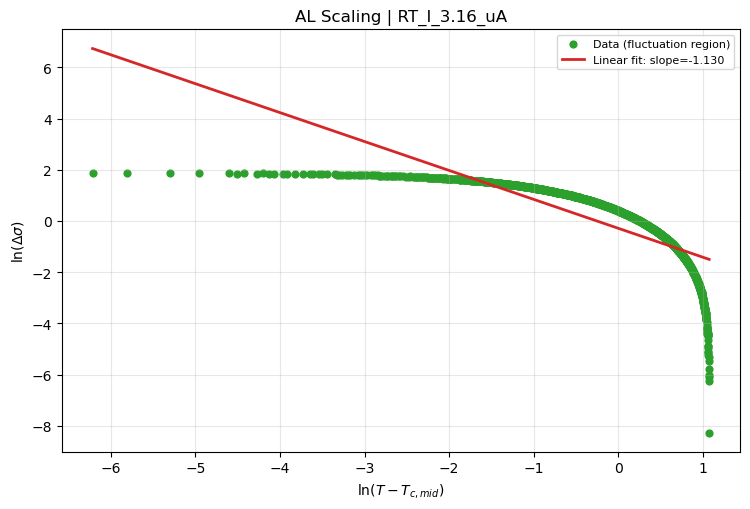

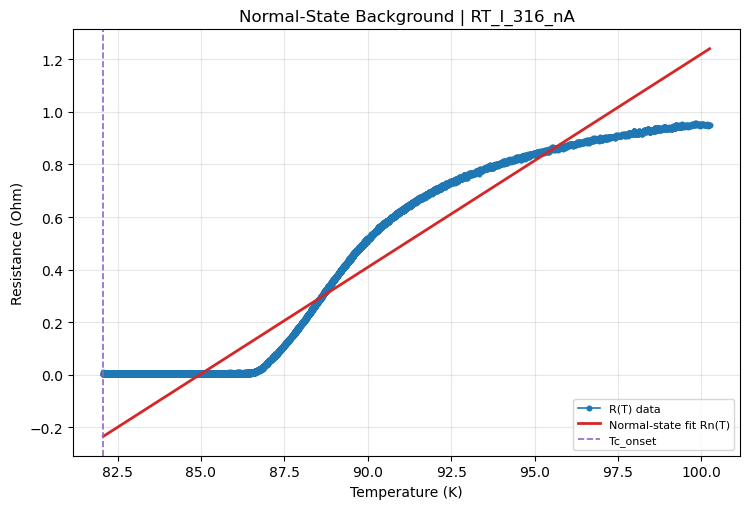

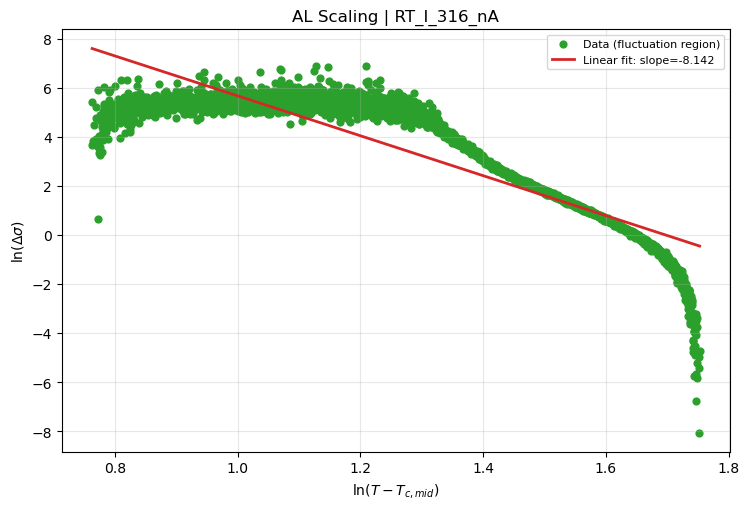

In [7]:
# 每組資料分開畫 AL 圖（分開獨立圖）
for res in analysis_results:
    if len(res['x_log']) < 4 or not np.isfinite(res['al_slope']):
        print(f"[AL skip] {res['dataset']}: 可用點不足。")
        continue

    T = res['T']
    R = res['R']
    Rn = res['Rn']
    x_log = res['x_log']
    y_log = res['y_log']

    # 圖1：背景擬合
    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    ax.plot(T, R, 'o-', ms=3.3, lw=1.2, color='tab:blue', label='R(T) data')
    ax.plot(T, Rn, '-', lw=2.0, color='tab:red', label='Normal-state fit Rn(T)')
    ax.axvline(res['Tc_onset'], ls='--', lw=1.2, color='tab:purple', label='Tc_onset')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Resistance (Ohm)')
    ax.set_title(f"Normal-State Background | {res['dataset']}")
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # 圖2：AL log-log
    fig, ax2 = plt.subplots(figsize=(7.6, 5.2))
    ax2.scatter(x_log, y_log, s=24, color='tab:green', label='Data (fluctuation region)')
    x_fit = np.linspace(np.min(x_log), np.max(x_log), 200)
    y_fit = res['al_slope'] * x_fit + res['al_intercept']
    ax2.plot(x_fit, y_fit, '-', color='tab:red', lw=2,
             label=f"Linear fit: slope={res['al_slope']:.3f}")
    ax2.set_xlabel(r'$\ln(T - T_{c,mid})$')
    ax2.set_ylabel(r'$\ln(\Delta\sigma)$')
    ax2.set_title(f"AL Scaling | {res['dataset']}")
    ax2.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 4) BKT Transition: Halperin-Nelson Fit

在轉變尾端（電阻已顯著下降但尚未為零）使用 BKT/Halperin-Nelson 常見形式擬合：

$$R(T)=R_0\exp\left[-\frac{b}{\sqrt{T/T_{BKT}-1}}\right], \quad T>T_{BKT}$$

從擬合可得到 $T_{BKT}$。

In [8]:
# BKT 數值摘要（每組資料一列）
bkt_rows = []
for res in analysis_results:
    bkt_rows.append({
        'dataset': res['dataset'],
        'BKT_T_BKT (K)': res['BKT_T_BKT'],
        'BKT_R0': res['BKT_R0'],
        'BKT_b': res['BKT_b'],
        'BKT_tail_points': len(res['T_tail']),
    })

bkt_df = pd.DataFrame(bkt_rows).sort_values('dataset').reset_index(drop=True)
display(bkt_df)


,dataset,BKT_T_BKT (K),BKT_R0,BKT_b,BKT_tail_points
0,RT_I_10_uA,86.137785,4.701943e+00,0.467840,1465
1,RT_I_1_uA,83.983000,1.857059e+00,0.283771,6763
2,RT_I_3.16_uA,85.642546,9.176933e+02,1.246880,301
3,RT_I_316_nA,82.074000,9.092303e+11,7.526035,734


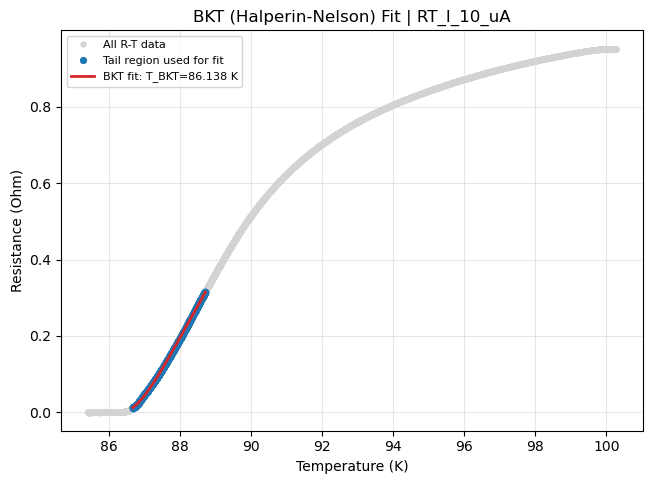

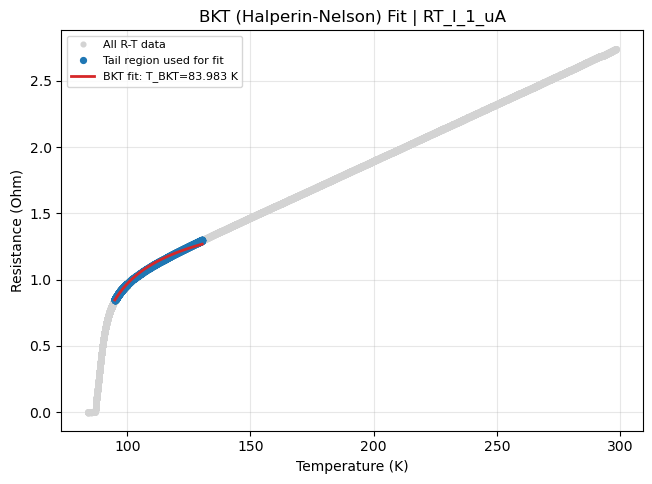

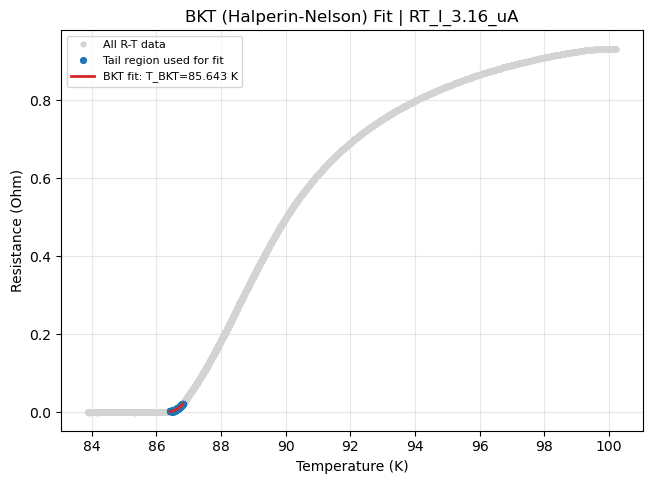

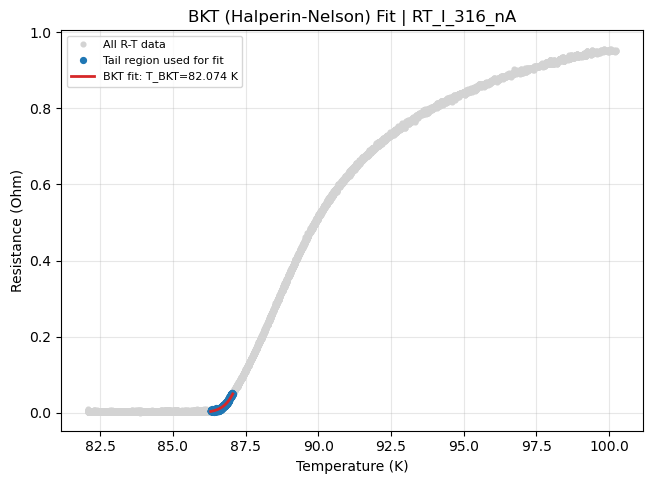

In [9]:
# 每組資料分開畫 BKT 擬合圖
for res in analysis_results:
    if len(res['T_tail']) < 6 or not np.isfinite(res['BKT_T_BKT']):
        print(f"[BKT skip] {res['dataset']}: tail 點數不足或擬合失敗。")
        continue

    T = res['T']
    R = res['R']
    T_tail = res['T_tail']
    R_tail = res['R_tail']

    T_plot = np.linspace(np.min(T_tail), np.max(T_tail), 300)
    reduced = np.clip(T_plot / max(res['BKT_T_BKT'], 1e-12) - 1.0, 1e-12, None)
    R_bkt_plot = res['BKT_R0'] * np.exp(-res['BKT_b'] / np.sqrt(reduced))

    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    ax.plot(T, R, 'o', ms=3.4, color='lightgray', label='All R-T data')
    ax.plot(T_tail, R_tail, 'o', ms=4.2, color='tab:blue', label='Tail region used for fit')
    ax.plot(T_plot, R_bkt_plot, '-', lw=2.0, color='tab:red',
            label=f"BKT fit: T_BKT={res['BKT_T_BKT']:.3f} K")
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Resistance (Ohm)')
    ax.set_title(f"BKT (Halperin-Nelson) Fit | {res['dataset']}")
    ax.legend(loc='best', fontsize=8)
    plt.show()
    plt.close(fig)


## Summary

此分析同時提供：

- 三種操作性臨界溫度 ($T_{c,\mathrm{onset}}$, $T_{c,\mathrm{mid}}$, $T_{c,\mathrm{zero}}$)
- 2D AL 漲落導電指數（理想 2D 期望斜率約 -1）
- BKT 擬合得到的 $T_{BKT}$

若要做更嚴謹比較，建議後續加入：誤差棒、不同電流條件比較、與磁場依賴交叉驗證。

In [10]:
# 總表：所有 RT（已排除 2probe）
summary_rows = []
for res in analysis_results:
    summary_rows.append({
        'dataset': res['dataset'],
        'Tc_onset (K)': res['Tc_onset'],
        'Tc_mid (K)': res['Tc_mid'],
        'Tc_zero (K)': res['Tc_zero'],
        'R_normal_ref (Ohm)': res['R_normal_ref'],
        'Noise_threshold (Ohm)': res['noise_threshold'],
        'AL_slope': res['al_slope'],
        'AL_intercept': res['al_intercept'],
        'BKT_T_BKT (K)': res['BKT_T_BKT'],
        'BKT_R0': res['BKT_R0'],
        'BKT_b': res['BKT_b'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
display(summary_df)


,dataset,Tc_onset (K),Tc_mid (K),Tc_zero (K),R_normal_ref (Ohm),Noise_threshold (Ohm),AL_slope,AL_intercept,BKT_T_BKT (K),BKT_R0,BKT_b
0,RT_I_10_uA,89.741,88.653,86.645,0.611480,0.009953,-1.093987,-1.231854,86.137785,4.701943e+00,0.467840
1,RT_I_1_uA,87.419,89.473,92.014,0.866640,0.706625,-1.171301,-0.288870,83.983000,1.857059e+00,0.283771
2,RT_I_3.16_uA,87.101,87.510,86.424,0.218990,0.002190,-1.130029,-0.287612,85.642546,9.176933e+02,1.246880
3,RT_I_316_nA,82.074,82.871,86.300,0.004075,0.002301,-8.142165,13.813832,82.074000,9.092303e+11,7.526035
